# 카드를 한 번도 안 쓴 552개 법인 — 완전 정복 노트북

> **한 줄 결론 먼저:** 이 552개는 "돈이 없는 회사"가 아니라 **"돈은 잘 쓰는데 카드만 안 쓰는 회사"**다.
> 이들이 카드를 쓰기 시작하면 **연 59억원**(보수적으로 36억원) 규모의 새 시장이 열린다.

---

### 이 노트북을 읽는 법

- 각 장은 **질문 하나**로 시작합니다. 코드는 그 질문에 숫자로 답하는 도구일 뿐이라, 코드를 건너뛰고 굵은 글씨만 읽어도 흐름이 이어집니다.
- 분석 로직은 팀 최종본(`무사용법인.ipynb`)과 동일합니다. 이 파일은 **설명을 쉽게 다시 쓴 버전**입니다.

### 3분 용어 사전 (이것만 알면 끝)

| 용어 | 쉬운 말 |
|---|---|
| **여신** | 은행이 빌려준 돈 = **대출** |
| **수신** | 은행에 맡긴 돈 = **예금** |
| **요구불예금** | 자유롭게 넣다 뺐다 하는 **입출금 통장** |
| **결제성 지출** | 통장에서 빠져나간 돈(요구불 출금 + 자동이체) = **회사가 실제로 쓴 돈** |
| **중앙값** | 일렬로 세웠을 때 딱 가운데 값. 극단값에 안 흔들려서 평균보다 정직함 |
| **백만원 단위** | 이 데이터의 금액 단위. `27.3` = 2,730만원, `335` = 3.35억원 |


---
## Q1. "552개"는 어떻게 나온 숫자인가?

전체 15,473개 법인에서 그냥 "카드 안 쓴 회사"를 센 게 아닙니다. **세 번 걸러서** 나온 숫자예요.

1. **36개월 내내 데이터가 있는 법인만** 남긴다 — 중간에 관측이 끊긴 법인은 "안 쓴 건지, 기록이 없는 건지" 구분 자체가 불가능하므로.
2. **1위 왜곡 법인 1개 제외** — 이 한 곳이 전체 카드 사용액의 39.9%를 혼자 쓴다(2위는 0.96%). 어떤 평균이든 이 법인 하나가 다 비틀어 버림.
3. 남은 법인 중 **36개월 카드 사용액 합계가 정확히 0원**인 법인 = **552개**.


In [1]:
# ============================================================
# 준비 — 데이터를 열고, 552가 어떻게 세어진 숫자인지 재현
# ============================================================
import sys, os, warnings
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import NearestNeighbors

from common import IM, SEED, set_korean_font, load_data, ID, YM, CARD
np.random.seed(SEED)
set_korean_font()

df = load_data()
print(f'원본: 법인 {df[ID].nunique():,}개, 총 {len(df):,}행 (법인×월)')

# [거름망 1] 36개월 모두 관측된 법인만
cnt = df.groupby(ID)[YM].nunique()
d1 = df[df[ID].isin(cnt[cnt == 36].index)].copy()
print(f'[거름망 1] 36개월 완전관측 → {d1[ID].nunique():,}개')

# [거름망 2] 카드 총액 1위 왜곡 법인 제외
tot = d1.groupby(ID)[CARD].sum().sort_values(ascending=False)
dominant = tot.index[0]
print(f'[거름망 2] 1위 법인 1개 제외 (혼자 전체 카드액의 {tot.iloc[0] / tot.sum():.1%})')

# [거름망 3] 카드 총액 0원 = 무사용
zero_ids = set(tot[tot == 0].index)
user_ids = set(tot.index) - {dominant} - zero_ids
print(f'[거름망 3] 카드 총액 0원 → 무사용 {len(zero_ids)}개 / 1원이라도 쓴 사용군 {len(user_ids):,}개')

원본: 법인 15,473개, 총 365,988행 (법인×월)
[거름망 1] 36개월 완전관측 → 3,372개


[거름망 2] 1위 법인 1개 제외 (혼자 전체 카드액의 39.9%)
[거름망 3] 카드 총액 0원 → 무사용 552개 / 1원이라도 쓴 사용군 2,819개


---
## Q2. 카드를 3년간 한 번도 안 썼다면… 유령 회사 아닌가?

가장 먼저 드는 의심입니다. 확인 방법은 간단합니다 — **카드 말고 다른 거래**를 보면 됩니다.

- 은행에서 **대출**을 받고 있나? (관계가 살아있나)
- **통장에서 돈이 나가나?** (사업을 실제로 하나)

아래 셀에서 법인별 "성적표"(월평균 프로필)를 만들고 팩트체크합니다.


In [2]:
# ============================================================
# 법인별 월평균 프로필 만들기 (2023.02~2025.12 = 35개월 기준)
#   ※ 2023.01은 전 법인의 카드값이 0으로 기록된 수집 오류 달이라 제외
# ============================================================
d1['총수신'] = d1[['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액']].sum(axis=1)  # 예금 전부
d1['총여신'] = d1['여신_운전자금대출잔액'] + d1['여신_시설자금대출잔액']   # 대출 전부
d1['결제성지출'] = d1['요구불출금금액'] + d1['자동이체금액']              # 실제로 쓴 돈

M = d1[d1[YM] >= 202302].groupby(ID).agg(
    카드월평균=(CARD, 'mean'),
    요구불출금=('요구불출금금액', 'mean'), 요구불입금=('요구불입금금액', 'mean'),
    자동이체=('자동이체금액', 'mean'), 인터넷뱅킹=('인터넷뱅킹거래금액', 'mean'),
    총여신=('총여신', 'mean'), 총수신=('총수신', 'mean'), 결제성지출=('결제성지출', 'mean'))
snap = d1[d1[YM] == 202512].set_index(ID)
M['업종'] = snap['업종_대분류']
M['신용카드보유'] = snap['신용카드개수'].str.strip() != '0개'
M['그룹'] = np.select([M.index.isin(zero_ids), M.index.isin(user_ids)], ['무사용', '사용'], default='제외')
M = M[M['그룹'] != '제외']
USERS = M[M['그룹'] == '사용']   # 사용군 2,819
ZEROS = M[M['그룹'] == '무사용'] # 무사용군 552
print(M['그룹'].value_counts().to_dict())

{'사용': 2819, '무사용': 552}


In [3]:
# ============================================================
# 팩트체크 — "유령 회사" 의심을 숫자로 확인
# ============================================================
z = ZEROS
print('■ 의심 1) 은행과 관계가 끊긴 회사 아닐까?')
print(f'   → 아니다. {(z["총여신"] > 0).mean():.1%}({(z["총여신"] > 0).sum()}개)가 대출 보유 중.')
print(f'     대출 보유 법인의 대출잔액 중앙값 = {z.loc[z["총여신"] > 0, "총여신"].median():,.0f}백만원 (약 3.4억원)')
print(f'     단, 예금 중앙값은 {z["총수신"].median():,.1f}백만원으로 사용군({USERS["총수신"].median():,.1f})의 1/5 수준')
print(f'     ⇒ 대출 "하나로만" 이어진 반쪽 관계')
print()
print('■ 의심 2) 사업 활동(지출)이 없는 회사 아닐까?')
print(f'   → 아니다. 결제성 지출(통장에서 나간 돈) 월 중앙값 = {z["결제성지출"].median():,.1f}백만원 (약 2,700만원)')
print(f'     월 1천만원 이상 쓰는 곳: {(z["결제성지출"] >= 10).sum()}개 ({(z["결제성지출"] >= 10).mean():.1%})')
print(f'     월 1억원 이상 쓰는 곳:  {(z["결제성지출"] >= 100).sum()}개 ({(z["결제성지출"] >= 100).mean():.1%})')
print(f'     ⇒ 돈은 쓰고 있다. 카드가 아닌 계좌이체로 쓸 뿐')
print()
print('■ 그럼 카드는 아예 없나?')
print(f'   → 신용카드를 발급받고 잠재운 법인(휴면 보유): {z["신용카드보유"].sum()}개 ({z["신용카드보유"].mean():.1%})')
print(f'     나머지는 카드 자체가 없음. 체크카드 사용 경험은 552개 전부 0')

■ 의심 1) 은행과 관계가 끊긴 회사 아닐까?
   → 아니다. 95.5%(527개)가 대출 보유 중.
     대출 보유 법인의 대출잔액 중앙값 = 335백만원 (약 3.4억원)
     단, 예금 중앙값은 10.1백만원으로 사용군(56.2)의 1/5 수준
     ⇒ 대출 "하나로만" 이어진 반쪽 관계

■ 의심 2) 사업 활동(지출)이 없는 회사 아닐까?
   → 아니다. 결제성 지출(통장에서 나간 돈) 월 중앙값 = 27.3백만원 (약 2,700만원)
     월 1천만원 이상 쓰는 곳: 368개 (66.7%)
     월 1억원 이상 쓰는 곳:  152개 (27.5%)
     ⇒ 돈은 쓰고 있다. 카드가 아닌 계좌이체로 쓸 뿐

■ 그럼 카드는 아예 없나?
   → 신용카드를 발급받고 잠재운 법인(휴면 보유): 98개 (17.8%)
     나머지는 카드 자체가 없음. 체크카드 사용 경험은 552개 전부 0


### 정리 — 유령이 아니라 "반쪽 고객"

| 의심 | 실제 |
|---|---|
| 관계가 끊긴 회사? | **95.5%가 대출 보유** (중앙값 3.4억원) — 관계는 살아있음 |
| 사업을 안 하는 회사? | 통장에선 **월 2,700만원**(중앙값)이 나감. 4곳 중 1곳은 월 1억+ |
| 카드를 못 만드는 회사? | 98개는 이미 카드가 있는데 **안 꺼내 쓰는 것**(휴면) |

한 문장으로: **"돈은 많이 쓰는데 카드만 안 쓰는, 대출로만 연결된 고객"** — 카드 사업 입장에서 **미개척 시장**입니다.


---
## Q3. 그럼 왜 안 쓰는 걸까?

전부 같은 이유는 아닙니다. **업종**을 보면 이유가 두 갈래로 갈립니다.

비교 방법: 무사용군(552) 안에서의 업종 비중을 사용군(2,819) 안에서의 비중과 비교합니다.
어떤 업종이 무사용군에 **비정상적으로 많이** 몰려 있다면, 그 업종은 "원래 카드 쓸 일이 없는" 업종일 가능성이 높습니다.


                          무사용수   무사용    사용  편중배율
업종                                              
제조업                        141  25.5  33.8  0.76
부동산업                       120  21.7   5.3  4.11
도매 및 소매업                    98  17.8  21.6  0.82
건설업                         57  10.3  18.7  0.55
운수 및 창고업                    23   4.2   4.2  0.99
협회 및 단체, 수리 및 기타 개인 서비스업    22   4.0   2.1  1.87
사업시설 관리, 사업 지원 및 임대 서비스업    21   3.8   3.1  1.25
전문, 과학 및 기술 서비스업            15   2.7   2.4  1.13


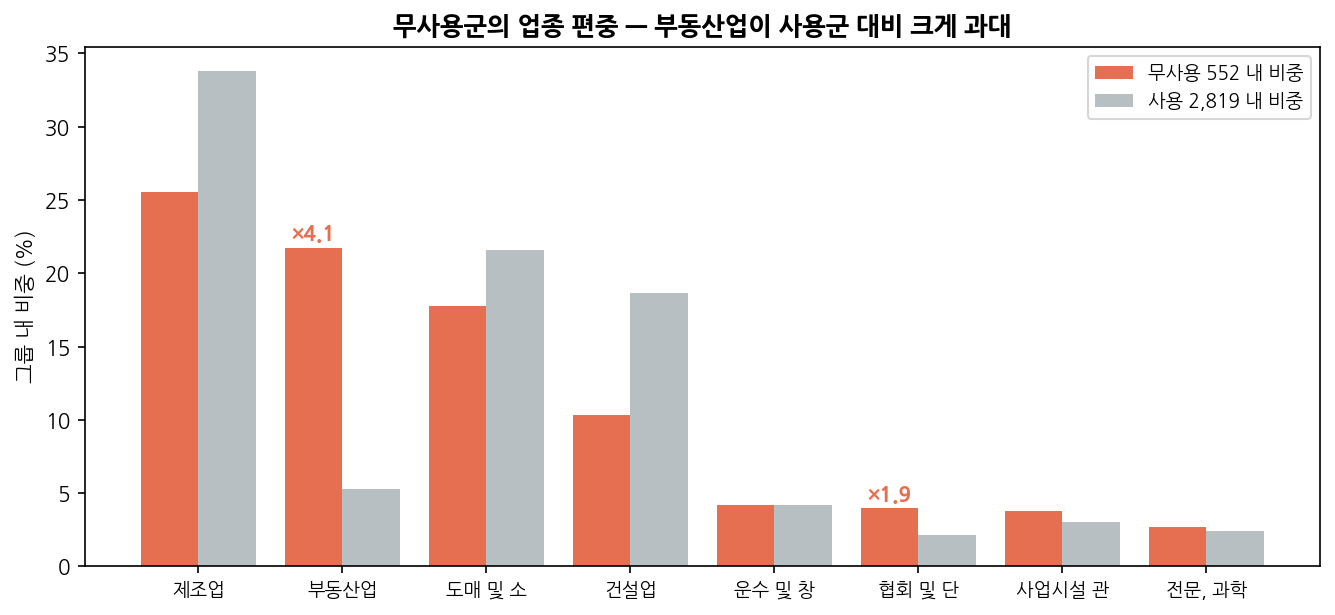

In [4]:
# ============================================================
# 업종 편중 — 무사용군에 어떤 업종이 비정상적으로 많은가
# ============================================================
comp = pd.DataFrame({'무사용': ZEROS['업종'].value_counts(normalize=True),
                     '사용': USERS['업종'].value_counts(normalize=True)})
comp['편중배율'] = comp['무사용'] / comp['사용']   # 1보다 크면 무사용군에 과대
comp['무사용수'] = ZEROS['업종'].value_counts()
comp = comp.sort_values('무사용', ascending=False).head(8)
print(comp[['무사용수']].join((comp[['무사용', '사용']] * 100).round(1)).join(comp[['편중배율']].round(2)).to_string())

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp['무사용'] * 100, 0.4, color=IM['코랄'], label='무사용 552 내 비중')
ax.bar(x + 0.2, comp['사용'] * 100, 0.4, color=IM['중립'], label='사용 2,819 내 비중')
for i, r in enumerate(comp['편중배율']):
    if r >= 1.5:
        ax.annotate(f'×{r:.1f}', (i - 0.2, comp['무사용'].iloc[i] * 100 + 0.5),
                    ha='center', fontsize=10, color=IM['코랄'], fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([s[:6] for s in comp.index], fontsize=9)
ax.set_ylabel('그룹 내 비중 (%)')
ax.set_title('무사용군의 업종 편중 — 부동산업이 사용군 대비 크게 과대', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 정리 — 안 쓰는 이유는 두 갈래

- **부동산업 120개 (무사용군의 21.7%, 사용군 대비 약 4배)** — 부동산 법인은 자재비·소모품·접대비처럼 **카드로 결제할 지출 자체가 구조적으로 적습니다.** → **"구조적 미수요"**: 권해도 쓸 게 없는 그룹. 기대치를 낮춰야 함.
- **제조업 141개, 건설업 57개** — 이 업종들은 사용군에도 흔합니다. 즉 **같은 업종 동료들은 카드를 잘 쓰고 있는데** 이 법인들만 안 씁니다. → **"습관적 미사용"**: 안 쓸 이유가 없는데 안 쓰는, **전환 가능한 그룹.**

이 구분이 중요한 이유: 영업 자원을 **전환 가능한 쪽에** 집중해야 하기 때문입니다.


---
## Q4. 이들이 카드를 쓰기 시작하면, 얼마나 쓸까?

여기가 이 분석의 하이라이트입니다. 문제는 — **정답이 데이터에 없습니다.** 이 법인들은 카드를 써 본 적이 없으니까요.

### 아이디어: 쌍둥이에게 묻기

> 전학 온 학생의 수학 점수를 모른다면? → **그 학생과 공부 습관이 가장 비슷한 학생 10명**을 찾아, 그들의 수학 점수를 보면 됩니다.

똑같이 합니다:
1. 무사용 법인마다, **업종이 같고 통장의 돈 흐름이 가장 닮은** 사용 법인 10개(=쌍둥이)를 찾는다.
2. 그 쌍둥이 10개의 실제 카드 사용액의 **중앙값**을 "이 법인이 쓰게 되면 이 정도"의 기대치로 삼는다.

### 먼저: "닮았다"의 잣대를 무엇으로 잴까?

아무 변수나 쓰면 안 됩니다. **카드 사용액과 실제로 관련 있는 변수**로 닮음을 재야, 닮은 법인이 카드도 비슷하게 씁니다. 사용군 2,819개에서 확인해 봅니다.


In [5]:
# ============================================================
# 닮음의 잣대 고르기 — 카드 사용액과 상관 높은 변수는?
# ============================================================
cand = ['자동이체', '요구불입금', '요구불출금', '인터넷뱅킹', '총수신', '총여신']
corr = pd.Series({c: stats.spearmanr(USERS['카드월평균'], USERS[c]).statistic for c in cand})
print('카드 월평균과의 순위 상관 (사용군 2,819개 기준):')
print(corr.sort_values(ascending=False).round(3).to_string())
print()
print('→ 결제성 채널 4개(자동이체·입금·출금·인터넷뱅킹)가 높고, 예금(0.34)·대출(0.20)은 낮다')
print('→ 잣대는 채널 4개로 확정 (낮은 변수를 섞으면 "닮음"이 흐려짐 — 다음 셀에서 실증)')

SET_A = ['요구불출금', '요구불입금', '자동이체', '인터넷뱅킹']  # 채널 4개
SET_B = SET_A + ['총여신', '총수신']                           # 비교용: 대출·예금 추가

카드 월평균과의 순위 상관 (사용군 2,819개 기준):
자동이체     0.559
요구불입금    0.501
요구불출금    0.500
인터넷뱅킹    0.442
총수신      0.335
총여신      0.198

→ 결제성 채널 4개(자동이체·입금·출금·인터넷뱅킹)가 높고, 예금(0.34)·대출(0.20)은 낮다
→ 잣대는 채널 4개로 확정 (낮은 변수를 섞으면 "닮음"이 흐려짐 — 다음 셀에서 실증)


### 이 방법, 믿어도 되나? — "답을 아는 문제"로 모의고사

새 방법을 무사용군에 바로 쓰면 맞았는지 확인할 길이 없습니다. 그래서 **정답을 아는 사용군 2,819개로 모의고사**를 칩니다:

> 사용군 법인 하나를 골라 **카드값을 가린 뒤**, 나머지 사용군에서 쌍둥이를 찾아 기대치를 매기고, 가렸던 실제값과 비교한다. 이걸 2,819번 반복. (통계 용어로 leave-one-out 검증)

동시에 두 가지 선택지도 시험합니다 — 잣대(채널 4개 vs 채널+대출·예금), 쌍둥이 수(k=3, 5, 10).


In [6]:
# ============================================================
# 쌍둥이 매칭 함수 + 모의고사 (사용군 leave-one-out)
# ============================================================
# 금액은 격차가 커서 log를 취해 눌러준 뒤(1억과 10억을 '10배'로 인식), 평균 0/표준편차 1로 맞춰 거리 계산
Z = {c: (np.log1p(USERS[c]).mean(), np.log1p(USERS[c]).std()) for c in SET_B}

def embed(frame, cols):
    return np.column_stack([(np.log1p(frame[c]) - Z[c][0]) / Z[c][1] for c in cols]).astype('float64')

def match_twins(targets, cols, k, loo=False):
    """각 법인에 대해 같은 업종 사용군에서 가장 닮은 k개를 찾아:
       기대월액 = 쌍둥이 카드값의 중앙값 / 보수월액 = 하위 25% 값
       평균거리 = 쌍둥이들과 얼마나 닮았나(작을수록 닮음)
       합의도  = 쌍둥이들끼리 카드값이 비슷한가(작을수록 한목소리)"""
    out = pd.DataFrame(index=targets.index,
                       columns=['기대월액', '보수월액', '평균거리', '합의도'], dtype=float)
    for ind, tblk in targets.groupby('업종'):
        ublk = USERS[USERS['업종'] == ind]
        if len(ublk) < (2 if loo else 1):
            continue
        n_nb = min(k + 1 if loo else k, len(ublk))
        nn = NearestNeighbors(n_neighbors=n_nb).fit(embed(ublk, cols))
        dists, idx = nn.kneighbors(embed(tblk, cols))
        if loo:  # 모의고사에선 첫 이웃 = 자기 자신이므로 제외
            dists, idx = dists[:, 1:], idx[:, 1:]
        vals = ublk['카드월평균'].values
        for i, cid in enumerate(tblk.index):
            twins = vals[idx[i]]
            q1, q3 = np.quantile(twins, [0.25, 0.75])
            out.loc[cid] = [np.median(twins), q1, dists[i].mean(), (q3 - q1) / (np.median(twins) + 1)]
    return out

def loo_score(pred):
    actual = USERS['카드월평균']
    ok = pred.notna()
    rho = stats.spearmanr(actual[ok], pred[ok]).statistic       # 순위를 잘 맞추나
    pos = ok & (actual > 1)
    mape = (np.abs(pred[pos] - actual[pos]) / actual[pos]).median()  # 금액은 얼마나 빗나가나
    return rho, mape

results = {}
for name, cols in [('A: 채널 4개', SET_A), ('B: 채널 4개+대출·예금', SET_B)]:
    for k in [3, 5, 10]:
        rho, mape = loo_score(match_twins(USERS, cols, k, loo=True)['기대월액'])
        results[(name, k)] = rho
        print(f'{name}, 쌍둥이 {k}개: 순위 맞추기 {rho:.3f} / 금액 중앙 오차 {mape:.0%}')

best_name, BEST_K = max(results, key=results.get)
BEST_COLS = SET_A if best_name.startswith('A') else SET_B
print(f'\n채택: {best_name}, 쌍둥이 {BEST_K}개 (순위 상관 최고)')

A: 채널 4개, 쌍둥이 3개: 순위 맞추기 0.499 / 금액 중앙 오차 54%


A: 채널 4개, 쌍둥이 5개: 순위 맞추기 0.541 / 금액 중앙 오차 51%


A: 채널 4개, 쌍둥이 10개: 순위 맞추기 0.578 / 금액 중앙 오차 47%


B: 채널 4개+대출·예금, 쌍둥이 3개: 순위 맞추기 0.494 / 금액 중앙 오차 55%


B: 채널 4개+대출·예금, 쌍둥이 5개: 순위 맞추기 0.524 / 금액 중앙 오차 54%


B: 채널 4개+대출·예금, 쌍둥이 10개: 순위 맞추기 0.567 / 금액 중앙 오차 48%

채택: A: 채널 4개, 쌍둥이 10개 (순위 상관 최고)


### 모의고사 결과 읽는 법

- **채널 4개(A)가 대출·예금을 추가한 B를 모든 조건에서 이겼습니다.** 카드와 상관이 낮은 변수를 섞으면 "닮음"이 오히려 흐려진다는 예측이 맞았습니다.
- 최고 성적은 **순위 상관 약 0.58** — 금액을 정확히 맞추는 능력은 약하지만(중앙 오차 ±50% 수준), **"누가 많이 쓸 법인인지 줄 세우는 능력"은 쓸 만합니다.**
- 그래서 이 추정치의 공식 용도는 처음부터 **"공략 우선순위 리스트"**입니다. "A법인은 월 17백만원 쓸 것"(✗)이 아니라 **"A법인이 상위권이라는 판단은 믿을 만하다"**(○).


---
## Q5. 552개 전부에 기대액을 매겨도 되나? — "확실"만 골라내기

전부 믿으면 정직하지 않습니다. 매칭의 질이 법인마다 다르기 때문입니다. 두 가지 기준으로 거릅니다:

1. **합의도** — 쌍둥이 10개의 카드값이 서로 비슷한가? 10명이 "월 15~20 정도"로 한목소리면 믿을 만하고, "3"부터 "80"까지 제각각이면 못 믿습니다.
2. **평균거리** — 애초에 충분히 닮은 쌍둥이를 찾긴 했나? 너무 멀면 "닮은 사람이 없어서 아무나 데려온 것"(외삽).

임계값도 자의적으로 정하지 않고 **사용군 모의고사에서 가져옵니다** — 합의도는 사용군의 중앙값 이하, 거리는 사용군의 90% 지점 이하.


임계: 합의도 ≤ 0.73 (사용군 중앙값) & 평균거리 ≤ 0.89 (사용군 90% 지점)

[검증] 등급이 정말 정확도를 가르나? (모의고사 성적 비교)
   확실: 1,312개 — 순위 상관 0.634
   참고: 1,507개 — 순위 상관 0.523
   → 확실 등급에서 순위 신뢰도가 실제로 더 높다. 기준이 작동한다는 증거


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


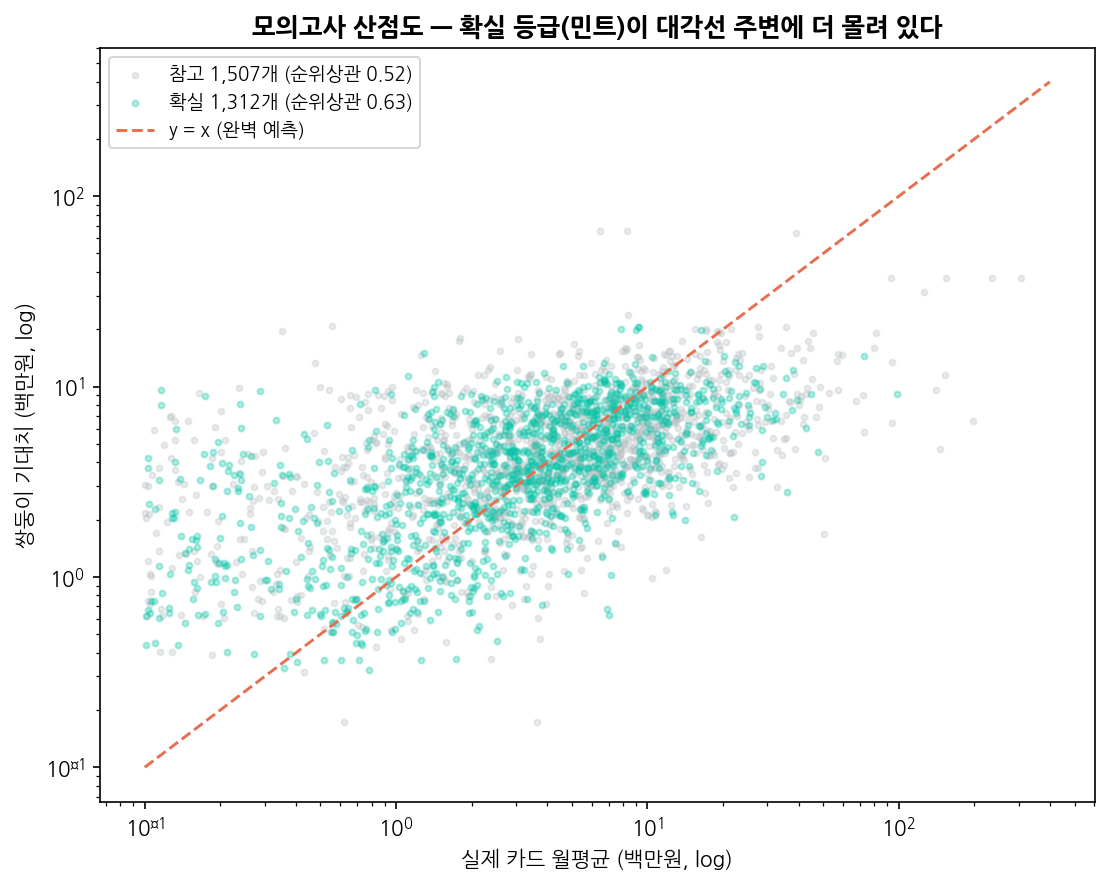

In [7]:
# ============================================================
# "확실 / 참고" 등급 나누기 + 등급이 실제로 정확도를 가르는지 검증
# ============================================================
LOO = match_twins(USERS, BEST_COLS, BEST_K, loo=True)   # 모의고사 결과(정답 있음)
EST = match_twins(ZEROS, BEST_COLS, BEST_K)             # 552 실제 추정(정답 없음)

AGREE_THR = LOO['합의도'].median()
DIST_THR = LOO['평균거리'].quantile(0.90)
print(f'임계: 합의도 ≤ {AGREE_THR:.2f} (사용군 중앙값) & 평균거리 ≤ {DIST_THR:.2f} (사용군 90% 지점)')

def grade(t):
    ok = (t['합의도'] <= AGREE_THR) & (t['평균거리'] <= DIST_THR)
    return np.where(t['기대월액'].isna(), '매칭불가', np.where(ok, '확실', '참고'))

LOO['신뢰도'] = grade(LOO)
EST['신뢰도'] = grade(EST)

actual = USERS['카드월평균']
print('\n[검증] 등급이 정말 정확도를 가르나? (모의고사 성적 비교)')
for g in ['확실', '참고']:
    m = LOO['신뢰도'] == g
    rho = stats.spearmanr(actual[m], LOO.loc[m, '기대월액']).statistic
    print(f'   {g}: {m.sum():,}개 — 순위 상관 {rho:.3f}')
print('   → 확실 등급에서 순위 신뢰도가 실제로 더 높다. 기준이 작동한다는 증거')

fig, ax = plt.subplots(figsize=(7.5, 6))
for g, color, zo in [('참고', IM['중립'], 1), ('확실', IM['민트'], 2)]:
    m = LOO['신뢰도'] == g
    rho = stats.spearmanr(actual[m], LOO.loc[m, '기대월액']).statistic
    ax.scatter(actual[m] + 0.1, LOO.loc[m, '기대월액'] + 0.1, s=8, alpha=0.3,
               color=color, zorder=zo, label=f'{g} {m.sum():,}개 (순위상관 {rho:.2f})')
lim = max(actual.max(), LOO['기대월액'].max()) * 1.3
ax.plot([0.1, lim], [0.1, lim], color=IM['코랄'], ls='--', lw=1.4, label='y = x (완벽 예측)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('실제 카드 월평균 (백만원, log)'); ax.set_ylabel('쌍둥이 기대치 (백만원, log)')
ax.set_title('모의고사 산점도 — 확실 등급(민트)이 대각선 주변에 더 몰려 있다', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

---
## Q6. 결론 — 얼마짜리 시장이고, 누구부터 가야 하나?

이제 552개에 매긴 기대액을 **확실 등급만** 공식 인용하고, 우선순위 리스트를 만듭니다.


신뢰도 분포: {'확실': 286, '참고': 266}

★ 확실 286개 — 기대 월 490백만원 = 연 59억원
   보수적으로 봐도(쌍둥이 하위 25% 기준): 연 36억원
   상위 30개가 확실 전체의 41% (월 199백만원) → 30곳만 돌아도 절반 가까이 커버

(참고 266개 몫은 매칭 품질 미달 — 공식 수치에서 제외, 상한 참고로만)


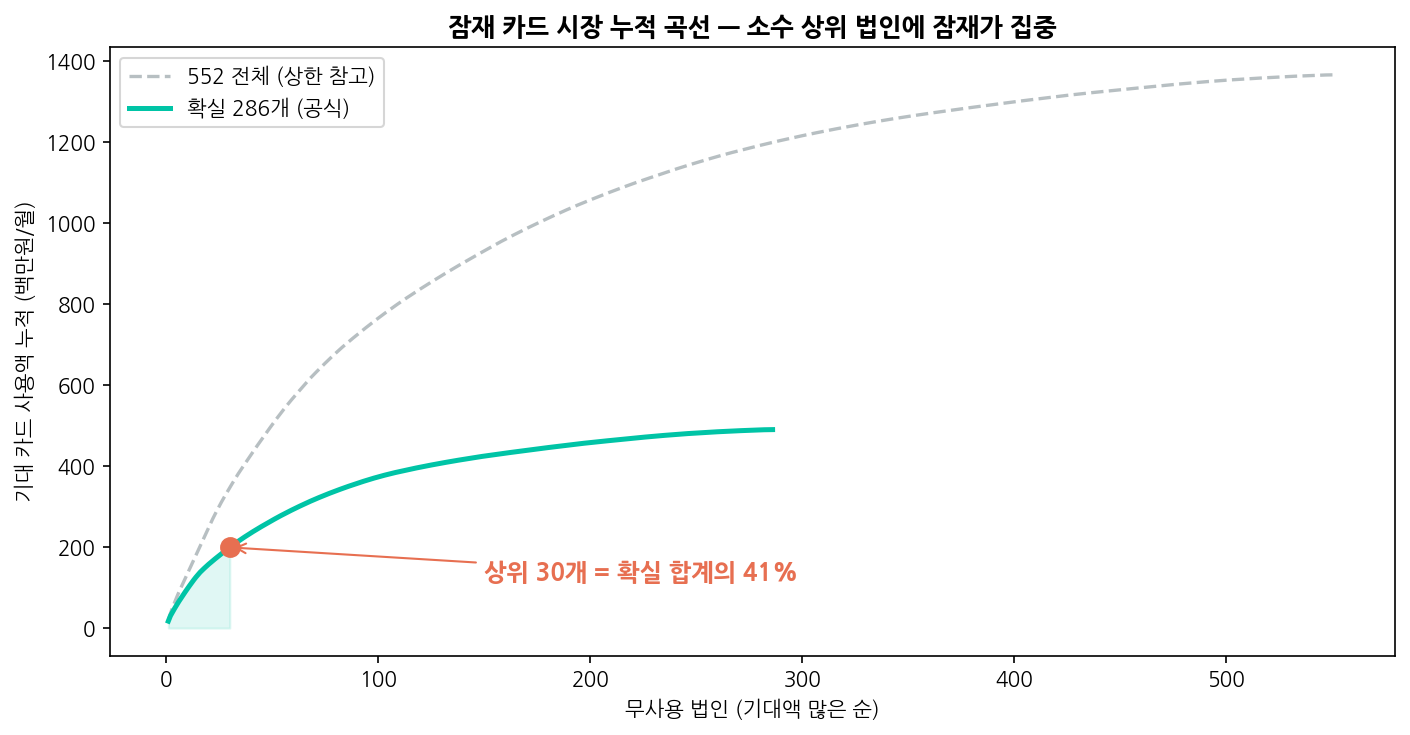

In [8]:
# ============================================================
# 잠재 시장 집계 — 확실 등급만 공식 인용
# ============================================================
est = EST.copy()
est['업종'] = M.loc[est.index, '업종']
est = est.sort_values(['신뢰도', '기대월액'], ascending=[True, False],
                      key=lambda s: s.map({'확실': 0, '참고': 1, '매칭불가': 2}) if s.name == '신뢰도' else s)

conf = est[est['신뢰도'] == '확실']
tot_conf, tot_cons = conf['기대월액'].sum(), conf['보수월액'].sum()
top30 = conf['기대월액'].head(30).sum()

print(f'신뢰도 분포: {est["신뢰도"].value_counts().to_dict()}')
print(f'\n★ 확실 {len(conf)}개 — 기대 월 {tot_conf:,.0f}백만원 = 연 {tot_conf * 12 / 100:,.0f}억원')
print(f'   보수적으로 봐도(쌍둥이 하위 25% 기준): 연 {tot_cons * 12 / 100:,.0f}억원')
print(f'   상위 30개가 확실 전체의 {top30 / tot_conf:.0%} (월 {top30:,.0f}백만원) → 30곳만 돌아도 절반 가까이 커버')
print(f'\n(참고 {len(est) - len(conf)}개 몫은 매칭 품질 미달 — 공식 수치에서 제외, 상한 참고로만)')

fig, ax = plt.subplots(figsize=(9.5, 5))
cum_c = conf['기대월액'].cumsum().values
cum_all = est['기대월액'].sort_values(ascending=False).cumsum().values
ax.plot(range(1, len(cum_all) + 1), cum_all, color=IM['중립'], lw=1.6, ls='--', label='552 전체 (상한 참고)')
ax.plot(range(1, len(cum_c) + 1), cum_c, color=IM['민트'], lw=2.4, label=f'확실 {len(conf)}개 (공식)')
ax.fill_between(range(1, 31), 0, cum_c[:30], color=IM['민트'], alpha=0.12)
ax.plot([30], [cum_c[29]], 'o', ms=9, color=IM['코랄'])
ax.annotate(f'상위 30개 = 확실 합계의 {top30 / tot_conf:.0%}', xy=(30, cum_c[29]),
            xytext=(150, cum_c[29] * 0.6), fontsize=11.5, color=IM['코랄'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=IM['코랄']))
ax.set_xlabel('무사용 법인 (기대액 많은 순)'); ax.set_ylabel('기대 카드 사용액 누적 (백만원/월)')
ax.set_title('잠재 카드 시장 누적 곡선 — 소수 상위 법인에 잠재가 집중', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

---
## Q7. "언제" 제안해야 먹히나? — 자연실험

마지막 퍼즐은 타이밍입니다. 다행히 데이터 안에 힌트가 있습니다 —
**한동안 카드를 안 쓰다가 뒤늦게 처음 쓰기 시작한 법인들.** (2023.08 이후 첫 사용 = 최소 6개월 무사용 선행)

이들이 카드를 쓰기 **직전에 무슨 일이 있었는지** 보면, "무사용 → 사용" 전환의 방아쇠를 알 수 있습니다.


In [9]:
# ============================================================
# 자연실험 — 뒤늦게 카드를 쓰기 시작한 법인들, 직전에 무슨 일이?
# ============================================================
months = sorted(d1[YM].unique())
card_mat = d1.pivot_table(index=ID, columns=YM, values=CARD).reindex(columns=months)
active = card_mat > 0
first_idx = np.where(active.values.any(axis=1), active.values.argmax(axis=1), -1)
first_s = pd.Series(first_idx, index=card_mat.index)

late_ids = first_s[(first_s >= months.index(202308)) & first_s.index.isin(user_ids)].index
print(f'후발 활성화 법인: {len(late_ids)}개 (2023.08 이후 처음 카드 사용)')

loan_mat = d1.pivot_table(index=ID, columns=YM, values='총여신').reindex(columns=months)

# 활성화 직전 6개월 사이 대출이 늘어난 법인 비율 vs 무사용군의 아무 시점 6개월
pre_up = [loan_mat.loc[cid].iloc[t0 - 1] > loan_mat.loc[cid].iloc[t0 - 7]
          for cid, t0 in first_s[late_ids].items() if t0 - 7 >= 0]
rng = np.random.RandomState(SEED)
base_up = []
for cid in rng.choice(sorted(zero_ids), 400, replace=False):
    t0 = rng.randint(8, 35)
    base_up.append(loan_mat.loc[cid].iloc[t0 - 1] > loan_mat.loc[cid].iloc[t0 - 7])

print(f'\n직전 6개월간 대출이 늘어난 비율:')
print(f'   카드를 쓰기 시작한 법인들 = {np.mean(pre_up):.1%}')
print(f'   무사용군 임의 시점(평상시) = {np.mean(base_up):.1%}')
print(f'   → 약 {np.mean(pre_up) / np.mean(base_up):.1f}배. 사업이 커지는 순간(대출 이벤트)이 카드를 쓰기 시작하는 계기')

후발 활성화 법인: 101개 (2023.08 이후 처음 카드 사용)

직전 6개월간 대출이 늘어난 비율:
   카드를 쓰기 시작한 법인들 = 20.8%
   무사용군 임의 시점(평상시) = 7.8%
   → 약 2.7배. 사업이 커지는 순간(대출 이벤트)이 카드를 쓰기 시작하는 계기


### 정리 — 타이밍의 근거

카드를 쓰기 시작한 법인들은 **직전 6개월에 대출이 늘어난 비율이 평상시의 약 2.5배**였습니다(대조군은 무작위 표본이라 실행마다 2.5~2.7배 사이에서 소폭 달라집니다).
사업이 커지는 순간(대출 신규·증액)에 법인카드 수요도 함께 생긴다는 뜻입니다.

→ 실행 규칙: **"대출 신규·증액 후 4주 안에 카드를 제안한다"** — 아무 때나 전화하는 것보다 훨씬 유리한 타이밍.


---

# 최종 요약 — 한 장

**스토리 5줄:**
1. 552개는 유령이 아니다 — **95.5%가 대출 보유, 월 2,700만원(중앙값)을 통장으로 지출**하는 "카드만 안 쓰는" 고객이다.
2. 안 쓰는 이유는 두 갈래 — 부동산업은 **구조적 미수요**(×4 편중), 제조·건설은 **습관적 미사용**(전환 가능).
3. 얼마나 쓸지는 본인 데이터에 답이 없어 **쌍둥이(업종 같고 돈 흐름 닮은 사용 법인 10개)에게 물었다.** 방법은 정답을 아는 사용군 2,819개 모의고사로 검증(순위상관 0.58).
4. 전부 믿지 않았다 — 쌍둥이끼리 한목소리이고(합의도) 충분히 닮은(거리) **"확실 매칭" 286개만** 공식 인용. 확실 등급은 모의고사에서 실제로 더 정확했다(0.63 vs 0.52).
5. 그 결과가 **잠재 연 59억원(보수 36억), 상위 30개가 41%** — 그리고 제안 타이밍은 **대출 신규·증액 직후**(자연실험 약 2.5배).

**실행 3종:**
1. **확실 등급 기대액 상위 30~50개** = 우선 공략 리스트 (30곳만 돌아도 잠재의 41%)
2. **타이밍은 대출 이벤트** — 신규·증액 후 4주 내 카드 제안 (자연실험 근거)
3. **부동산업은 기대치 관리** — 확실 등급에 들어도 잠재 최저 (구조적 미수요가 매칭에서 자동 반영됨)

**정직한 한계 3가지 (인용 시 반드시 병기):**
- 기대액은 "전환 성공 시" 상한 — 전환 확률(발급 거절, 타행 카드)은 데이터에 없음.
- 확실 등급이 보증하는 건 **순서**다. 개별 금액 오차는 ±50% 수준 — "이 법인이 상위권"까지만 믿을 것.
- 무사용군은 발급·첫 사용 이벤트가 관측되지 않아 지도학습(예측 모델)이 불가능 — 쌍둥이 매칭은 이 제약 안에서의 최선.

**공식 산출물:** `outputs/tables/07_쌍둥이매칭_552기대액.csv` (법인별 기대액·신뢰도, 우선순위 정렬)
